In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib

In [2]:
df = pd.read_csv("youtube_ad_revenue_dataset_featured.csv")

In [ ]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate,watch_per_view,views_per_minute
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.155093,2.666789,3471.532423
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.098632,1.518393,421.980413
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.214519,5.678187,385.372360
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.142814,3.122834,852.481742
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.236121,1.584151,1490.237760


In [10]:
# Features & Setting Target

X = df.drop(columns=[
    "video_id",
    "date",
    "ad_revenue_usd"
])

y = df["ad_revenue_usd"]

In [11]:
# Setting Categorical & Numerical Column

categorical_cols = [
    "category",
    "device",
    "country"
]

numerical_cols = [
    "views",
    "likes",
    "comments",
    "watch_time_minutes",
    "video_length_minutes",
    "subscribers",
    "engagement_rate",
    "watch_per_view",
    "views_per_minute"
]

In [12]:
# Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [13]:
# Test Train Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
# Defining Models

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [15]:
# Model Training & Evaluation

results = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score,MAE,RMSE
2,Lasso Regression,0.952587,3.075400,13.478245
1,Ridge Regression,0.952580,3.109978,13.479258
0,Linear Regression,0.952573,3.114634,13.480137
4,Gradient Boosting,0.952223,3.616577,13.529776
3,Random Forest,0.949932,3.563501,13.850394


In [16]:
# Selecting best model

best_model = GradientBoostingRegressor(random_state=42)

best_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
# Final Prediction

y_pred = best_pipe.predict(X_test)

In [18]:
# Final Metrics

print("R2 Score:", r2_score(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9522234078226842
MAE: 3.61657716512605
RMSE: 13.529775676504583


In [19]:
# Feature Importance

feature_names = (
    best_pipe.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_values = (
    best_pipe.named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
19,remainder__watch_time_minutes,0.977806
22,remainder__engagement_rate,0.021250
17,remainder__likes,0.000442
16,remainder__views,0.000304
23,remainder__watch_per_view,0.000101
18,remainder__comments,0.000027
21,remainder__subscribers,0.000016
20,remainder__video_length_minutes,0.000014
11,cat__country_CA,0.000011
7,cat__device_Mobile,0.000009


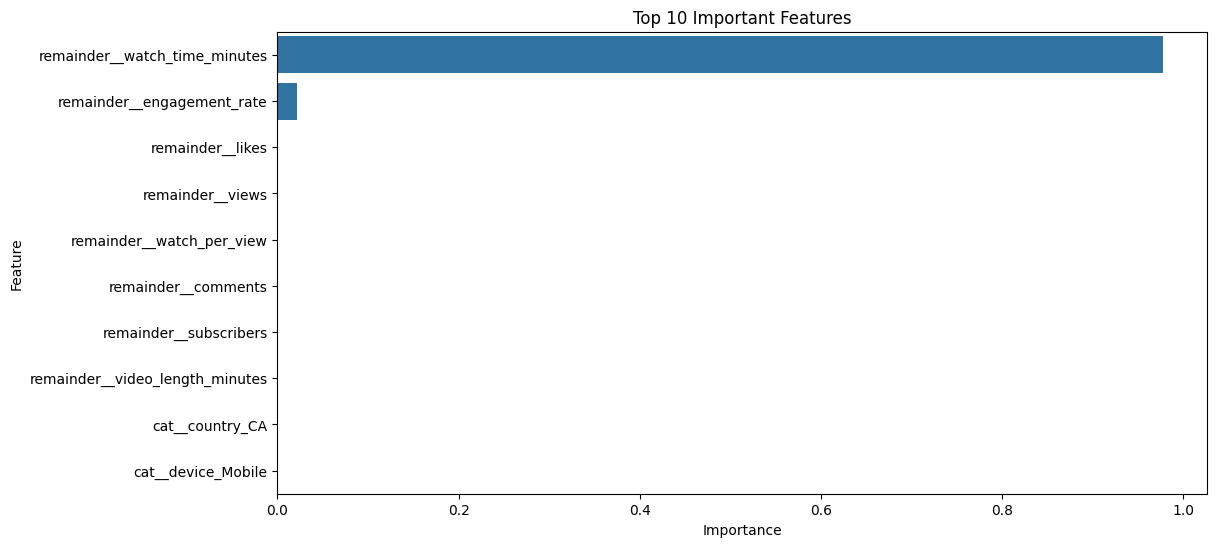

In [20]:
# Plotting Feature Importance

plt.figure(figsize=(12,6))

sns.barplot(
    x=importance_df["Importance"].head(10),
    y=importance_df["Feature"].head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [21]:
# Saving Model

joblib.dump(best_pipe, "best_youtube_model.pkl")

['best_youtube_model.pkl']